# 01. Data Analysis

UCI Hydraulic System 원본 데이터를 확인하고 EDA를 수행한 뒤,
**센서별 평균(mean) 17개 특징만** 생성한다.

### 최종 기준
1. 10초 / 20초 / 30초 / 60초 평균 특징 생성
2. 축압기 원본 라벨 `90 / 100 / 115 / 130` 기준 Stratified 70/15/15
3. 생성한 Train / Validation / Test `cycle_id`를 네 부품이 공통 사용
4. 시간순서 분할은 최종 분할로 사용하지 않음

## 1. 라이브러리 및 경로 설정

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split

# Matplotlib 한글 폰트 설정 - Windows
from matplotlib import font_manager

font_path = r"C:\Windows\Fonts\malgun.ttf"
font_name = font_manager.FontProperties(
    fname=font_path
).get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print("Matplotlib 한글 폰트 :", font_name)

Matplotlib 한글 폰트 : Malgun Gothic


### 1-1. 데이터 경로 설정

In [2]:
DATA_DIR = Path(
    "../data/raw/uci_hydraulic/extracted"
)

processed_dir = Path(
    "../data/processed"
)

processed_dir.mkdir(
    parents=True,
    exist_ok=True
)

### 1-2. 데이터 경로 확인

In [3]:
print(
    "원본 데이터 폴더:",
    DATA_DIR.resolve()
)

print(
    "존재 여부:",
    DATA_DIR.exists()
)

if not DATA_DIR.exists():
    raise FileNotFoundError(
        "원본 데이터 폴더를 찾지 못했습니다."
    )

원본 데이터 폴더: C:\ai-first-project\data\raw\uci_hydraulic\extracted
존재 여부: True


### 1-3. 센서 목록과 샘플링 속도

In [4]:
sensor_names = [
    "PS1", "PS2", "PS3", "PS4", "PS5", "PS6",
    "EPS1",
    "FS1", "FS2",
    "TS1", "TS2", "TS3", "TS4",
    "VS1",
    "CE", "CP", "SE"
]

sampling_rates = {
    "PS1": 100, "PS2": 100, "PS3": 100,
    "PS4": 100, "PS5": 100, "PS6": 100,
    "EPS1": 100,
    "FS1": 10, "FS2": 10,
    "TS1": 1, "TS2": 1, "TS3": 1, "TS4": 1,
    "VS1": 1,
    "CE": 1, "CP": 1, "SE": 1
}

mean_feature_cols = [
    f"{sensor}_mean"
    for sensor in sensor_names
]

component_order = [
    "cooler",
    "valve",
    "pump",
    "accumulator"
]

## 2. 원본 데이터 확인

### 2-1. 필수 파일 목록 확인

In [5]:
sensor_files = [
    f"{sensor}.txt"
    for sensor in sensor_names
]

required_files = (
    sensor_files
    + ["profile.txt"]
)

missing_files = [
    file_name
    for file_name in required_files
    if not (
        DATA_DIR / file_name
    ).exists()
]

### 2-2. 누락 파일 검사

In [6]:
if missing_files:
    raise FileNotFoundError(
        f"필수 파일이 없습니다: {missing_files}"
    )

print(
    "센서 파일:",
    len(sensor_files),
    "개"
)

print(
    "profile.txt: 확인"
)

센서 파일: 17 개
profile.txt: 확인


### 2-3. profile.txt 불러오기

In [7]:
profile = pd.read_csv(
    DATA_DIR / "profile.txt",
    sep=r"\s+",
    header=None
)

profile.columns = [
    "cooler",
    "valve",
    "pump",
    "accumulator",
    "stable_flag"
]

profile.insert(
    0,
    "cycle_id",
    range(1, len(profile) + 1)
)

### 2-4. profile 데이터 확인

In [8]:
display(
    profile.head()
)

print(
    "profile shape:",
    profile.shape
)

if len(profile) != 2205:
    raise ValueError(
        "profile.txt 사이클 수가 2205가 아닙니다."
    )

,cycle_id,cooler,valve,pump,accumulator,stable_flag
0,1,3,100,0,130,1
1,2,3,100,0,130,1
2,3,3,100,0,130,1
3,4,3,100,0,130,1
4,5,3,100,0,130,1


profile shape: (2205, 6)


## 3. 센서 구조 확인

### 3-1. 센서 물리량과 단위 정의

In [9]:
sensor_types = {
    "PS1": "압력", "PS2": "압력", "PS3": "압력",
    "PS4": "압력", "PS5": "압력", "PS6": "압력",
    "EPS1": "모터 전력",
    "FS1": "유량", "FS2": "유량",
    "TS1": "온도", "TS2": "온도",
    "TS3": "온도", "TS4": "온도",
    "VS1": "진동",
    "CE": "냉각 효율",
    "CP": "냉각 출력",
    "SE": "효율 계수"
}

sensor_units = {
    "PS1": "bar", "PS2": "bar", "PS3": "bar",
    "PS4": "bar", "PS5": "bar", "PS6": "bar",
    "EPS1": "W",
    "FS1": "l/min", "FS2": "l/min",
    "TS1": "°C", "TS2": "°C",
    "TS3": "°C", "TS4": "°C",
    "VS1": "mm/s",
    "CE": "%", "CP": "kW", "SE": "%"
}

### 3-2. 센서 정보표 생성

In [10]:
sensor_info_df = pd.DataFrame({
    "센서명": sensor_names,
    "물리량": [
        sensor_types[sensor]
        for sensor in sensor_names
    ],
    "단위": [
        sensor_units[sensor]
        for sensor in sensor_names
    ],
    "샘플링 속도(Hz)": [
        sampling_rates[sensor]
        for sensor in sensor_names
    ],
    "60초당 값 수": [
        sampling_rates[sensor] * 60
        for sensor in sensor_names
    ]
})

display(
    sensor_info_df
)

,센서명,물리량,단위,샘플링 속도(Hz),60초당 값 수
0,PS1,압력,bar,100,6000
1,PS2,압력,bar,100,6000
2,PS3,압력,bar,100,6000
3,PS4,압력,bar,100,6000
4,PS5,압력,bar,100,6000
5,PS6,압력,bar,100,6000
6,EPS1,모터 전력,W,100,6000
7,FS1,유량,l/min,10,600
8,FS2,유량,l/min,10,600
9,TS1,온도,°C,1,60


### 3-3. 센서별 행·열 개수 검사

In [11]:
cycle_check = []

for sensor in sensor_names:
    sensor_df = pd.read_csv(
        DATA_DIR / f"{sensor}.txt",
        sep=r"\s+",
        header=None
    )

    expected_cols = (
        sampling_rates[sensor]
        * 60
    )

    cycle_check.append({
        "sensor": sensor,
        "rows": sensor_df.shape[0],
        "cols": sensor_df.shape[1],
        "expected_cols": expected_cols,
        "row_ok": (
            sensor_df.shape[0] == 2205
        ),
        "col_ok": (
            sensor_df.shape[1]
            == expected_cols
        )
    })

    del sensor_df

### 3-4. 센서 구조 검사 결과

In [12]:
cycle_check_df = pd.DataFrame(
    cycle_check
)

display(
    cycle_check_df
)

if not cycle_check_df["row_ok"].all():
    raise ValueError(
        "일부 센서의 사이클 수가 2205가 아닙니다."
    )

if not cycle_check_df["col_ok"].all():
    raise ValueError(
        "일부 센서의 열 개수가 예상과 다릅니다."
    )

,sensor,rows,cols,expected_cols,row_ok,col_ok
0,PS1,2205,6000,6000,True,True
1,PS2,2205,6000,6000,True,True
2,PS3,2205,6000,6000,True,True
3,PS4,2205,6000,6000,True,True
4,PS5,2205,6000,6000,True,True
5,PS6,2205,6000,6000,True,True
6,EPS1,2205,6000,6000,True,True
7,FS1,2205,600,600,True,True
8,FS2,2205,600,600,True,True
9,TS1,2205,60,60,True,True


## 3-5. 원본 documentation.txt 확인

UCI 데이터와 함께 제공된 `documentation.txt`에서
센서 샘플링 속도와 각 상태 라벨의 의미를 확인한다.

In [13]:
documentation_path = DATA_DIR / "documentation.txt"

if documentation_path.exists():
    with open(
        documentation_path,
        "r",
        encoding="cp1252"
    ) as file:
        documentation_text = file.read()

    print("documentation.txt 내용 :")
    print(documentation_text)
else:
    print("documentation.txt 파일을 찾지 못했습니다.")

documentation.txt 내용 :
1. Title: Condition monitoring of hydraulic systems

2. Source Information
   -- Creator: Nikolai Helwig, ZeMA gGmbH, Eschberger Weg 46, 66121 Saarbrücken
   -- Donors (with approval from creator): M. Bastuck (m.bastuck@lmt.uni-saarland.de), T. Schneider (t.schneider@zema.de)
   -- Date: April, 2018
 
3. Past Usage:
   [1] Nikolai Helwig, Eliseo Pignanelli, Andreas Schütze, ‘Condition Monitoring of a Complex Hydraulic System Using Multivariate Statistics’, in Proc. I2MTC-2015 - 2015 IEEE International Instrumentation and Measurement Technology Conference, paper PPS1-39, Pisa, Italy, May 11-14, 2015. doi: 10.1109/I2MTC.2015.7151267
      -- detailed description of data and measurement setup
      -- automated feature extraction via Pearson correlation and comparison of several classification algorithms
      -- Cooler and Valve states are "easy" targets (perfect classification achieved), Pump and especially Accumulator states are more complex targets

   [2] N. He

## 3-6. 라벨 상태 코드 의미

- 냉각기: `3 / 20 / 100`
- 밸브: `73 / 80 / 90 / 100`
- 펌프: `0 / 1 / 2`
- 축압기: `90 / 100 / 115 / 130`
- 안정 상태 플래그: `0 / 1`

`stable_flag`는 모델 입력 특징으로 사용하지 않는다.

In [14]:
label_meaning = {
    "cooler": {
        3: "close_to_total_failure",
        20: "reduced_efficiency",
        100: "full_efficiency"
    },
    "valve": {
        73: "close_to_total_failure",
        80: "severe_lag",
        90: "small_lag",
        100: "optimal"
    },
    "pump": {
        0: "no_leakage",
        1: "weak_leakage",
        2: "severe_leakage"
    },
    "accumulator": {
        90: "close_to_total_failure",
        100: "severely_reduced",
        115: "slightly_reduced",
        130: "optimal_pressure"
    }
}

for component, mapping in label_meaning.items():
    print(component, mapping)

cooler {3: 'close_to_total_failure', 20: 'reduced_efficiency', 100: 'full_efficiency'}
valve {73: 'close_to_total_failure', 80: 'severe_lag', 90: 'small_lag', 100: 'optimal'}
pump {0: 'no_leakage', 1: 'weak_leakage', 2: 'severe_leakage'}
accumulator {90: 'close_to_total_failure', 100: 'severely_reduced', 115: 'slightly_reduced', 130: 'optimal_pressure'}


## 4. 라벨 EDA

### 4-1. 부품별 클래스 분포

In [15]:
label_names = {
    "cooler": "냉각기",
    "valve": "밸브",
    "pump": "펌프",
    "accumulator": "축압기"
}

for component in component_order:
    print(
        f"\n[{label_names[component]}]"
    )

    print(
        profile[component]
        .value_counts()
        .sort_index()
    )


[냉각기]
cooler
3      732
20     732
100    741
Name: count, dtype: int64

[밸브]
valve
73      360
80      360
90      360
100    1125
Name: count, dtype: int64

[펌프]
pump
0    1221
1     492
2     492
Name: count, dtype: int64

[축압기]
accumulator
90     808
100    399
115    399
130    599
Name: count, dtype: int64


### 4-2. 부품별 클래스 분포 시각화

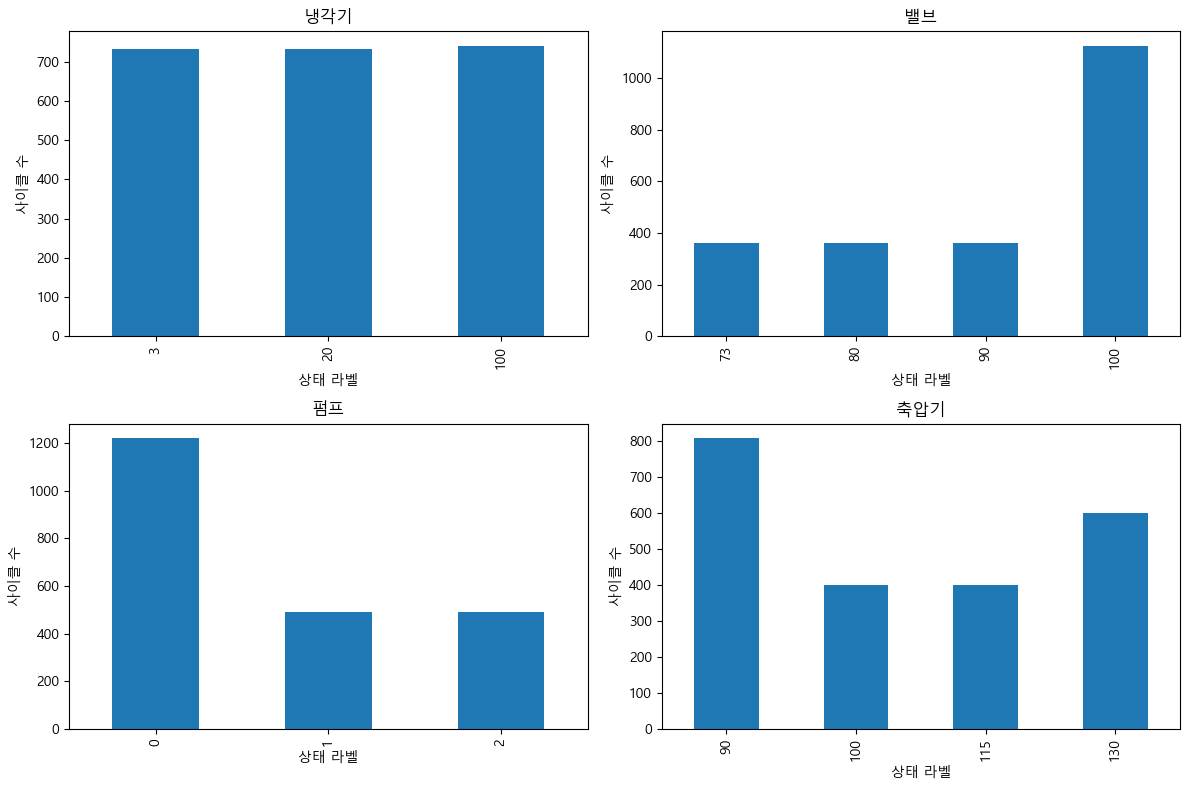

In [16]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8)
)

axes = axes.ravel()

for ax, component in zip(
    axes,
    component_order
):
    counts = (
        profile[component]
        .value_counts()
        .sort_index()
    )

    counts.plot(
        kind="bar",
        ax=ax
    )

    ax.set_title(
        label_names[component]
    )

    ax.set_xlabel(
        "상태 라벨"
    )

    ax.set_ylabel(
        "사이클 수"
    )

plt.tight_layout()
plt.show()

## 4-3. 기존 EDA - 펌프 정상 / 심각 누설 대표 cycle 선택

기존 EDA 흐름을 유지하기 위해 대표 cycle 두 개를 선택한다.
이 비교는 **설명용 EDA**이며 모델 입력 특징을 늘리는 용도가 아니다.

In [17]:
normal_cycle_id = profile.loc[
    profile["pump"] == 0,
    "cycle_id"
].iloc[0]

severe_cycle_id = profile.loc[
    profile["pump"] == 2,
    "cycle_id"
].iloc[0]

print("정상 펌프 cycle_id :", normal_cycle_id)
print("심각 누설 cycle_id :", severe_cycle_id)

정상 펌프 cycle_id : 1
심각 누설 cycle_id : 211


### 4-4. 정상 / 심각 누설 PS1 원본 신호 비교

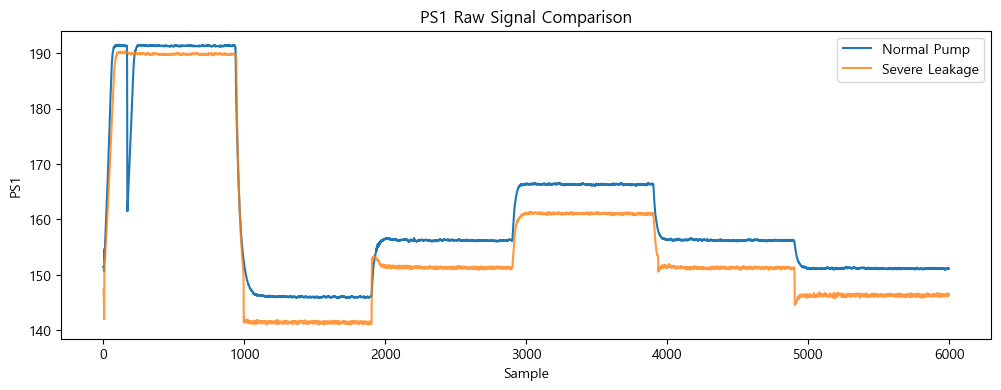

In [18]:
ps1_raw = pd.read_csv(
    DATA_DIR / "PS1.txt",
    sep=r"\s+",
    header=None
)

normal_ps1 = ps1_raw.iloc[
    normal_cycle_id - 1
].to_numpy(dtype=float)

severe_ps1 = ps1_raw.iloc[
    severe_cycle_id - 1
].to_numpy(dtype=float)

plt.figure(figsize=(12, 4))
plt.plot(normal_ps1, label="Normal Pump")
plt.plot(severe_ps1, label="Severe Leakage", alpha=0.8)
plt.title("PS1 Raw Signal Comparison")
plt.xlabel("Sample")
plt.ylabel("PS1")
plt.legend()
plt.show()

### 4-5. 정상 / 심각 누설 PS1 통계값 비교

In [19]:
print("[정상 펌프]")
print("평균 :", normal_ps1.mean())
print("표준편차 :", normal_ps1.std())
print("최솟값 :", normal_ps1.min())
print("최댓값 :", normal_ps1.max())

print()

print("[심각 누설]")
print("평균 :", severe_ps1.mean())
print("표준편차 :", severe_ps1.std())
print("최솟값 :", severe_ps1.min())
print("최댓값 :", severe_ps1.max())

[정상 펌프]
평균 : 160.67349166666665
표준편차 : 13.938146895896788
최솟값 : 145.83
최댓값 : 191.51

[심각 누설]
평균 : 156.39146166666666
표준편차 : 15.160827425095588
최솟값 : 141.02
최댓값 : 190.31


### 4-6. 기존 통계 특징 실험 유지

아래 셀은 기존 노트북에서 통계 특징의 의미를 이해하기 위해 사용한 EDA 실험이다.

**최종 모델 입력은 mean 17개만 사용한다.**
따라서 아래의 `std / min / max / range / rms / slope`는
설명용으로만 계산하며 최종 Parquet 특징에는 저장하지 않는다.

In [20]:
values = normal_ps1

mean_value = np.mean(values)
std_value = np.std(values)
min_value = np.min(values)
max_value = np.max(values)
range_value = max_value - min_value
rms_value = np.sqrt(np.mean(values ** 2))
slope_value = np.polyfit(
    np.arange(len(values)),
    values,
    1
)[0]

print("평균 :", mean_value)
print("표준편차 :", std_value)
print("최솟값 :", min_value)
print("최댓값 :", max_value)
print("범위 :", range_value)
print("RMS :", rms_value)
print("기울기 :", slope_value)

평균 : 160.67349166666665
표준편차 : 13.938146895896788
최솟값 : 145.83
최댓값 : 191.51
범위 : 45.67999999999998
RMS : 161.27691360901596
기울기 : -0.004043084019252369


## 5. 평균 특징 추출

최종 모델 입력은 센서별 `mean`만 사용한다.

- 센서 17개
- 특징 17개
- `std / min / max / range / slope / rms`는 최종 특징에서 제외

### 5-1. 입력 시간 구간 준비

In [21]:
windows = [
    10,
    20,
    30,
    60
]

features_by_window = {
    seconds: pd.DataFrame({
        "cycle_id":
            profile["cycle_id"].copy()
    })
    for seconds in windows
}

### 5-2. 센서별 평균 특징 계산

In [22]:
for sensor in sensor_names:
    print(
        "처리 중:",
        sensor
    )

    sensor_df = pd.read_csv(
        DATA_DIR / f"{sensor}.txt",
        sep=r"\s+",
        header=None
    )

    rate = sampling_rates[sensor]

    for seconds in windows:
        n_values = (
            rate
            * seconds
        )

        features_by_window[
            seconds
        ][
            f"{sensor}_mean"
        ] = (
            sensor_df
            .iloc[:, :n_values]
            .mean(axis=1)
            .to_numpy()
        )

    del sensor_df

처리 중: PS1
처리 중: PS2
처리 중: PS3
처리 중: PS4
처리 중: PS5
처리 중: PS6
처리 중: EPS1
처리 중: FS1
처리 중: FS2
처리 중: TS1
처리 중: TS2
처리 중: TS3
처리 중: TS4
처리 중: VS1
처리 중: CE
처리 중: CP
처리 중: SE


### 5-3. 시간별 특징 데이터프레임 분리

In [23]:
features_10s = (
    features_by_window[10]
)

features_20s = (
    features_by_window[20]
)

features_30s = (
    features_by_window[30]
)

features_60s = (
    features_by_window[60]
)

### 5-4. 특징 컬럼 순서 확인

In [24]:
expected_columns = (
    ["cycle_id"]
    + mean_feature_cols
)

for seconds, features in (
    features_by_window.items()
):
    if (
        features.columns.tolist()
        != expected_columns
    ):
        raise ValueError(
            f"{seconds}초 특징 컬럼 순서가 다릅니다."
        )

    print(
        f"{seconds}초:",
        features.shape
    )

10초: (2205, 18)
20초: (2205, 18)
30초: (2205, 18)
60초: (2205, 18)


### 5-5. 특징 개수·결측값 검사

In [25]:
for seconds, features in (
    features_by_window.items()
):
    if features.shape != (
        2205,
        18
    ):
        raise ValueError(
            f"{seconds}초 특징 shape 오류: "
            f"{features.shape}"
        )

    if (
        features
        .isna()
        .any()
        .any()
    ):
        raise ValueError(
            f"{seconds}초 특징에 결측값이 있습니다."
        )

print(
    "평균 특징 17개 검사 완료"
)

평균 특징 17개 검사 완료


## 6. 평균 특징 EDA

### 6-1. 축압기 라벨과 60초 특징 결합

In [26]:
accumulator_eda = (
    features_60s
    .merge(
        profile[
            [
                "cycle_id",
                "accumulator"
            ]
        ],
        on="cycle_id"
    )
)

representative = [
    "PS1_mean",
    "FS1_mean",
    "TS1_mean",
    "VS1_mean"
]

### 6-2. 축압기 상태별 대표 특징 분포

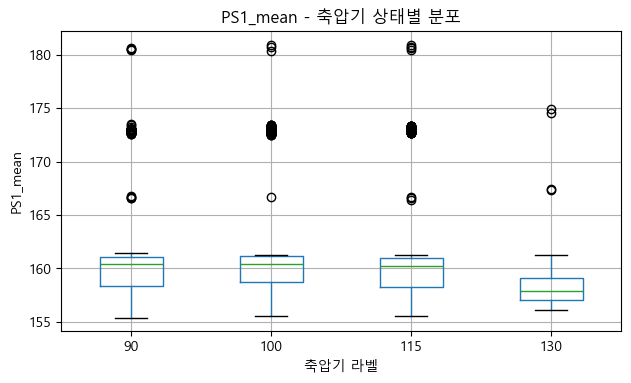

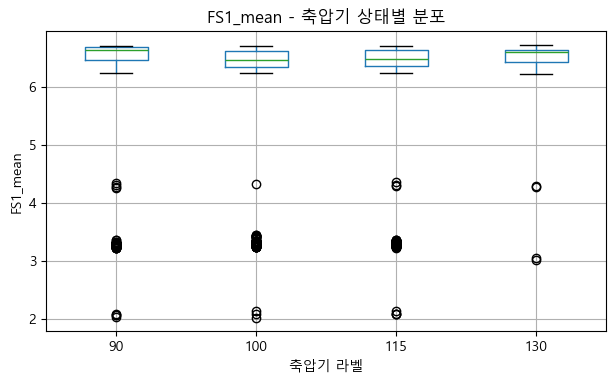

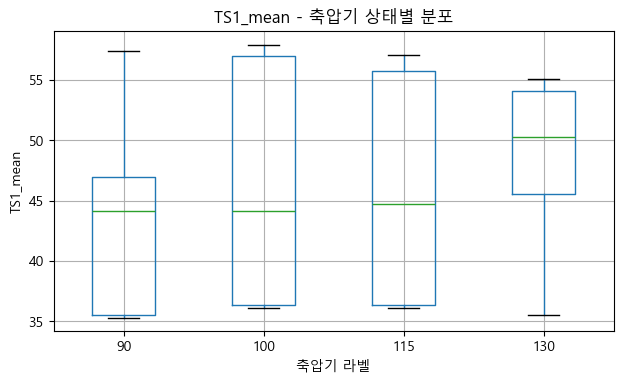

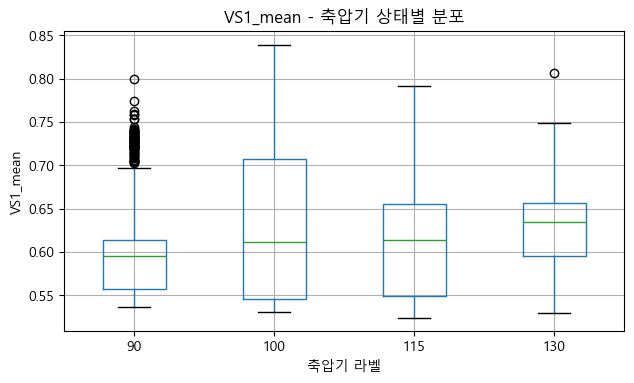

In [27]:
for feature in representative:
    accumulator_eda.boxplot(
        column=feature,
        by="accumulator",
        figsize=(7, 4)
    )

    plt.title(
        f"{feature} - 축압기 상태별 분포"
    )

    plt.suptitle("")
    plt.xlabel("축압기 라벨")
    plt.ylabel(feature)
    plt.show()

## 7. 특징 파일 저장

### 7-1. 저장 대상 구성

In [28]:
feature_outputs = {
    "features_10s.parquet":
        features_10s,
    "features_20s.parquet":
        features_20s,
    "features_30s.parquet":
        features_30s,
    "features_60s.parquet":
        features_60s
}

### 7-2. Parquet 저장

In [29]:
for file_name, features in (
    feature_outputs.items()
):
    save_path = (
        processed_dir
        / file_name
    )

    features.to_parquet(
        save_path,
        index=False
    )

    print(
        "저장:",
        save_path,
        features.shape
    )

저장: ..\data\processed\features_10s.parquet (2205, 18)
저장: ..\data\processed\features_20s.parquet (2205, 18)
저장: ..\data\processed\features_30s.parquet (2205, 18)
저장: ..\data\processed\features_60s.parquet (2205, 18)


## 7-3. EDA - 대표 센서 평균 특징 분포

PS1(압력), FS1(유량), TS1(온도), VS1(진동)의 60초 평균 특징 분포를 확인한다.

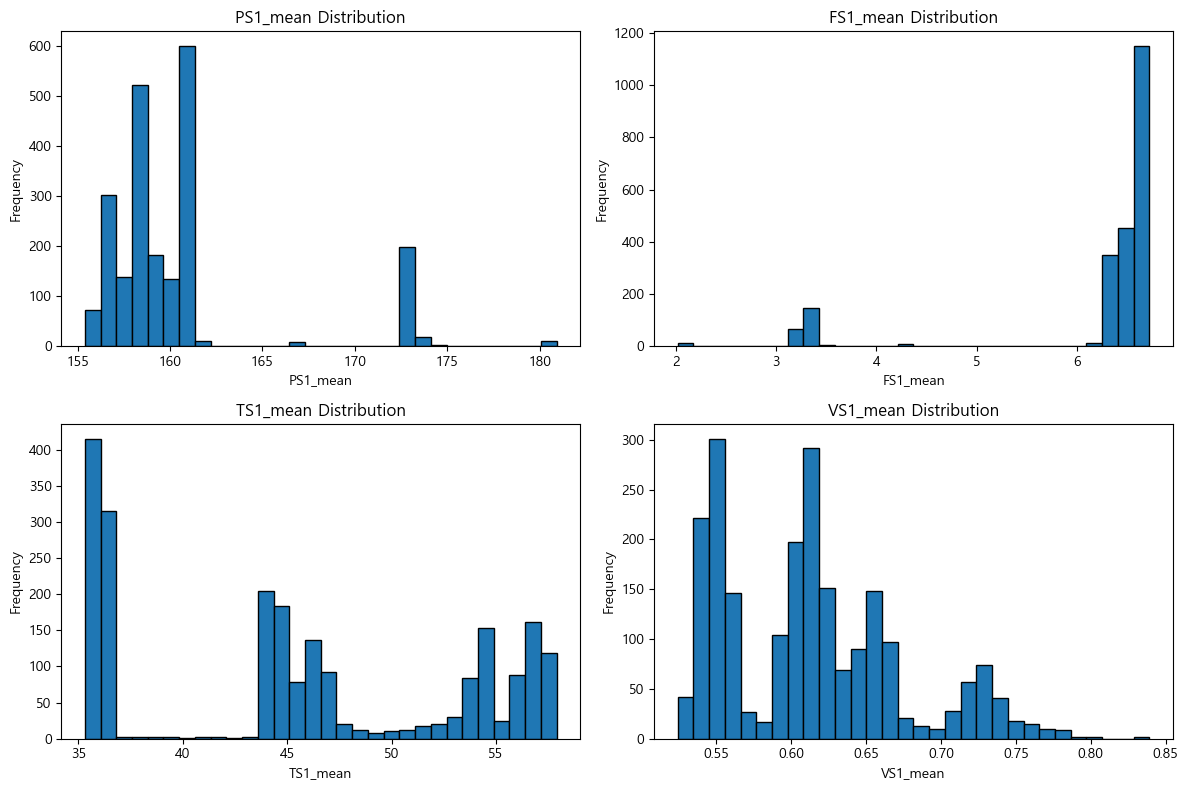

In [30]:
representative_features = [
    "PS1_mean",
    "FS1_mean",
    "TS1_mean",
    "VS1_mean"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, feature in zip(
    axes,
    representative_features
):
    ax.hist(
        features_60s[feature],
        bins=30,
        edgecolor="black"
    )
    ax.set_title(f"{feature} Distribution")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## 7-4. EDA 결과 요약

- 냉각기, 밸브, 펌프, 축압기의 상태별 표본 수가 동일하지 않음을 확인한다.
- 압력, 유량, 온도, 진동 대표 센서의 평균값 분포를 확인한다.
- 펌프 정상/심각 누설 대표 cycle의 PS1 신호 차이를 확인한다.
- 기존 통계 특징 실험은 설명용으로 유지하지만, **최종 모델 입력은 평균 17개만 사용한다.**

## 8. Train / Validation / Test 분할

축압기 원본 라벨 `90 / 100 / 115 / 130` 기준으로
Stratified 70/15/15를 한 번만 수행한다.

### 8-1. 축압기 기준 분할 함수

In [31]:
def make_accumulator_stratified_split(
    profile,
    random_state=42
):
    # 전체의 15%를 Test로 분리
    dev_ids, test_ids = train_test_split(
        profile["cycle_id"],
        test_size=0.15,
        random_state=random_state,
        stratify=profile["accumulator"]
    )

    # 남은 85% 중 전체의 15%를 Validation으로 분리
    dev_profile = profile[
        profile["cycle_id"].isin(dev_ids)
    ].copy()

    train_ids, val_ids = train_test_split(
        dev_profile["cycle_id"],
        test_size=0.15 / 0.85,
        random_state=random_state,
        stratify=dev_profile["accumulator"]
    )

    return (
        sorted(map(int, train_ids)),
        sorted(map(int, val_ids)),
        sorted(map(int, test_ids))
    )

### 8-2. 공통 cycle_id 생성

In [32]:
train_ids, val_ids, test_ids = (
    make_accumulator_stratified_split(
        profile,
        random_state=42
    )
)

### 8-3. 분할 개수 확인

In [33]:
print(
    "전체:",
    len(profile)
)

print(
    "Train:",
    len(train_ids)
)

print(
    "Validation:",
    len(val_ids)
)

print(
    "Test:",
    len(test_ids)
)

assert len(train_ids) == 1543
assert len(val_ids) == 331
assert len(test_ids) == 331

전체: 2205
Train: 1543
Validation: 331
Test: 331


### 8-4. cycle_id 중복 검사

In [34]:
train_set = set(train_ids)
val_set = set(val_ids)
test_set = set(test_ids)

assert not (
    train_set
    & val_set
)

assert not (
    train_set
    & test_set
)

assert not (
    val_set
    & test_set
)

assert len(
    train_set
    | val_set
    | test_set
) == len(profile)

print(
    "cycle_id 중복 0개"
)

cycle_id 중복 0개


### 8-5. 축압기 클래스 분포 확인

In [35]:
for split_name, ids in [
    ("Train", train_ids),
    ("Validation", val_ids),
    ("Test", test_ids)
]:
    print(
        f"\n[{split_name}]"
    )

    print(
        profile.loc[
            profile[
                "cycle_id"
            ].isin(ids),
            "accumulator"
        ]
        .value_counts()
        .sort_index()
    )


[Train]
accumulator
90     566
100    279
115    279
130    419
Name: count, dtype: int64

[Validation]
accumulator
90     121
100     60
115     60
130     90
Name: count, dtype: int64

[Test]
accumulator
90     121
100     60
115     60
130     90
Name: count, dtype: int64


### 8-6. 모든 분할에 4개 클래스 존재 여부 확인

In [36]:
for split_name, ids in [
    ("Train", train_ids),
    ("Validation", val_ids),
    ("Test", test_ids)
]:
    labels = set(
        profile.loc[
            profile[
                "cycle_id"
            ].isin(ids),
            "accumulator"
        ].unique()
    )

    assert labels == {
        90,
        100,
        115,
        130
    }, (
        f"{split_name} 라벨 오류: "
        f"{labels}"
    )

print(
    "축압기 4개 클래스 확인 완료"
)

축압기 4개 클래스 확인 완료


### 8-7. Stratified 분할 cycle_id 예시 확인

Stratified 분할은 시간순 연속 구간이 아니므로
`최솟값 ~ 최댓값`을 Train/Validation/Test의 실제 연속 범위로 해석하면 안 된다.
아래에서는 앞쪽 일부 ID만 확인한다.

In [37]:
print("Train 앞 10개 :", train_ids[:10])
print("Validation 앞 10개 :", val_ids[:10])
print("Test 앞 10개 :", test_ids[:10])

Train 앞 10개 : [1, 2, 3, 5, 6, 9, 10, 11, 12, 13]
Validation 앞 10개 : [4, 8, 15, 16, 18, 31, 32, 36, 43, 49]
Test 앞 10개 : [7, 17, 21, 22, 27, 29, 33, 37, 39, 46]


## 9. 분할 ID 저장

### 9-1. 분할 정보 구성

In [38]:
split_data = {
    "policy":
        "accumulator_4class_stratified_70_15_15",
    "random_state": 42,
    "stratify_column":
        "accumulator",
    "accumulator_labels": [
        90,
        100,
        115,
        130
    ],
    "train_ids": train_ids,
    "val_ids": val_ids,
    "test_ids": test_ids
}

### 9-2. JSON 저장

In [39]:
split_path = (
    processed_dir
    / "split_ids_accumulator_stratified.json"
)

with open(
    split_path,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        split_data,
        file,
        ensure_ascii=False,
        indent=2
    )

print(
    "저장:",
    split_path
)

저장: ..\data\processed\split_ids_accumulator_stratified.json


## 10. Test 정답 파일 저장

### 10-1. Test 라벨 추출

In [40]:
test_labels = (
    profile[
        profile[
            "cycle_id"
        ].isin(test_ids)
    ]
    .sort_values("cycle_id")
    .reset_index(drop=True)
)

### 10-2. test_labels.parquet 저장

In [41]:
test_label_path = (
    processed_dir
    / "test_labels.parquet"
)

test_labels.to_parquet(
    test_label_path,
    index=False
)

print(
    "저장:",
    test_label_path,
    test_labels.shape
)

저장: ..\data\processed\test_labels.parquet (331, 6)


## 11. 1초 단위 Test 재생 데이터

### 11-1. cycle_id × 60초 인덱스 생성

In [42]:
replay_index = pd.MultiIndex.from_product(
    [
        sorted(test_ids),
        range(1, 61)
    ],
    names=[
        "cycle_id",
        "elapsed_sec"
    ]
)

replay_test = (
    replay_index
    .to_frame(index=False)
)

### 11-2. Test 데이터 원본 위치 확인

In [43]:
test_positions = (
    profile[
        profile[
            "cycle_id"
        ].isin(test_ids)
    ]
    .sort_values("cycle_id")
    .index
    .to_numpy()
)

### 11-3. 센서별 1초 평균 재생값 생성

In [44]:
for sensor in sensor_names:
    print(
        "재생 데이터 처리:",
        sensor
    )

    sensor_df = pd.read_csv(
        DATA_DIR / f"{sensor}.txt",
        sep=r"\s+",
        header=None
    )

    rate = (
        sampling_rates[sensor]
    )

    sensor_array = (
        sensor_df
        .iloc[test_positions, :]
        .to_numpy()
    )

    one_second_mean = (
        sensor_array
        .reshape(
            len(test_ids),
            60,
            rate
        )
        .mean(axis=2)
        .reshape(-1)
    )

    replay_test[sensor] = (
        one_second_mean
    )

    del (
        sensor_df,
        sensor_array,
        one_second_mean
    )

재생 데이터 처리: PS1
재생 데이터 처리: PS2
재생 데이터 처리: PS3
재생 데이터 처리: PS4
재생 데이터 처리: PS5
재생 데이터 처리: PS6
재생 데이터 처리: EPS1
재생 데이터 처리: FS1
재생 데이터 처리: FS2
재생 데이터 처리: TS1
재생 데이터 처리: TS2
재생 데이터 처리: TS3
재생 데이터 처리: TS4
재생 데이터 처리: VS1
재생 데이터 처리: CE
재생 데이터 처리: CP
재생 데이터 처리: SE


### 11-4. 정답 라벨 미포함 검사

In [45]:
forbidden_label_cols = {
    "cooler",
    "valve",
    "pump",
    "accumulator",
    "stable_flag"
}

assert not (
    forbidden_label_cols
    & set(
        replay_test.columns
    )
)

print(
    "재생 파일에 정답 라벨 없음"
)

재생 파일에 정답 라벨 없음


### 11-5. replay_test.parquet 저장

In [46]:
replay_path = (
    processed_dir
    / "replay_test.parquet"
)

replay_test.to_parquet(
    replay_path,
    index=False
)

print(
    "저장:",
    replay_path,
    replay_test.shape
)

display(
    replay_test.head()
)

저장: ..\data\processed\replay_test.parquet (19860, 19)


,cycle_id,elapsed_sec,PS1,PS2,PS3,PS4,PS5,PS6,EPS1,FS1,FS2,TS1,TS2,TS3,TS4,VS1,CE,CP,SE
0,7,1,172.9192,11.76832,0.18163,0.0,9.26587,9.17530,2533.554,1.0712,10.1534,41.223,45.684,42.609,38.566,0.582,19.339,1.110,68.512
1,7,2,191.0517,0.10900,0.00000,0.0,9.26109,9.16843,2905.448,0.0012,10.1518,41.176,45.703,42.609,38.562,0.605,19.415,1.109,0.000
2,7,3,191.0487,0.00000,0.00000,0.0,9.25433,9.16076,2913.768,0.0018,10.1533,41.145,45.691,42.605,38.633,0.629,19.040,1.089,0.000
3,7,4,191.0017,0.00000,0.00000,0.0,9.25592,9.16497,2913.654,0.0013,10.1532,40.957,45.664,42.605,38.641,0.635,19.003,1.086,0.000
4,7,5,190.9875,0.00000,0.00000,0.0,9.26299,9.16942,2914.554,0.0016,10.1610,40.977,45.637,42.605,38.641,0.634,18.996,1.090,0.000


## 12. 최종 파일 확인

In [47]:
output_files = [
    "features_10s.parquet",
    "features_20s.parquet",
    "features_30s.parquet",
    "features_60s.parquet",
    "split_ids_accumulator_stratified.json",
    "test_labels.parquet",
    "replay_test.parquet"
]

for file_name in output_files:
    file_path = (
        processed_dir
        / file_name
    )

    print(
        file_name,
        "→",
        file_path.exists()
    )

features_10s.parquet → True
features_20s.parquet → True
features_30s.parquet → True
features_60s.parquet → True
split_ids_accumulator_stratified.json → True
test_labels.parquet → True
replay_test.parquet → True


## 13. Test 데이터 1초 단위 재생 결과 확인

### 13-1. Test cycle_id 확인

In [48]:
print("Test 사이클 개수 :", len(test_ids))
print("첫 Test cycle_id :", test_ids[0])
print("마지막 Test cycle_id :", test_ids[-1])

Test 사이클 개수 : 331
첫 Test cycle_id : 7
마지막 Test cycle_id : 2203


### 13-2. 각 Test cycle이 60초씩 있는지 확인

In [49]:
replay_counts = (
    replay_test
    .groupby("cycle_id")
    .size()
)

print("Test cycle 개수 :", replay_counts.shape[0])
print("최소 행 개수 :", replay_counts.min())
print("최대 행 개수 :", replay_counts.max())
print("모든 cycle이 60초인가? :", bool((replay_counts == 60).all()))

Test cycle 개수 : 331
최소 행 개수 : 60
최대 행 개수 : 60
모든 cycle이 60초인가? : True


## 14. Test 정답 라벨 파일 확인

### 14-1. Test cycle 정답 라벨 확인

In [50]:
display(test_labels.head())

print(
    "Test 라벨 cycle_id 개수 :",
    test_labels["cycle_id"].nunique()
)

,cycle_id,cooler,valve,pump,accumulator,stable_flag
0,7,3,100,0,130,1
1,17,3,100,0,130,1
2,21,3,100,0,130,1
3,22,3,100,0,130,1
4,27,3,100,0,130,1


Test 라벨 cycle_id 개수 : 331


### 14-2. Test cycle_id 일치 여부 확인

In [51]:
replay_test_ids = set(
    replay_test["cycle_id"].unique()
)

label_test_ids = set(
    test_labels["cycle_id"].unique()
)

print(
    "replay_test와 test_labels cycle_id 동일 :",
    replay_test_ids == label_test_ids
)

replay_test와 test_labels cycle_id 동일 : True


## 15. 데이터 생성 결과 최종 확인

최종 생성 파일:

- `features_10s.parquet`
- `features_20s.parquet`
- `features_30s.parquet`
- `features_60s.parquet`
- `replay_test.parquet`
- `test_labels.parquet`
- `split_ids_accumulator_stratified.json`

In [52]:
final_outputs = [
    "features_10s.parquet",
    "features_20s.parquet",
    "features_30s.parquet",
    "features_60s.parquet",
    "replay_test.parquet",
    "test_labels.parquet",
    "split_ids_accumulator_stratified.json"
]

for file_name in final_outputs:
    file_path = processed_dir / file_name
    print(file_name, ":", file_path.exists())

features_10s.parquet : True
features_20s.parquet : True
features_30s.parquet : True
features_60s.parquet : True
replay_test.parquet : True
test_labels.parquet : True
split_ids_accumulator_stratified.json : True
